In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process.binning import add_seg_info, group_bins
from cns.analyze.genome import fig_genome_groups
from cns.data_utils import  load_filter_samples, load_filter_bins, get_cns_for_type

In [3]:
samples = load_filter_samples()

In [4]:
cns = load_filter_bins(samples, "10MB")

In [5]:
samples["PCAWG"]["TCGA_type"].value_counts()[:6]

TCGA_type
LIRI    250
PACA    233
PBCA    230
BRCA    211
PRAD    158
OV      110
Name: count, dtype: int64

In [6]:
get_cns_for_type(cns["PCAWG"], samples["PCAWG"], "LUAD")

,sample_id,chrom,start,end,major_cn,minor_cn
0,SP50263,chr1,0,10127953,3.949543,0.050457
1,SP50263,chr1,10127953,20255906,4.000000,0.000000
2,SP50263,chr1,20255906,30383859,4.272085,0.000000
3,SP50263,chr1,30383859,40511811,3.428317,0.734227
4,SP50263,chr1,40511811,50639764,3.212776,0.787224
...,...,...,...,...,...,...
10665,SP56303,chrX,103249144,113653428,1.999055,1.999055
10666,SP56303,chrX,113653428,124057711,1.262085,1.262085
10667,SP56303,chrX,124057711,134461994,1.000000,1.000000
10668,SP56303,chrX,134461994,144866277,1.000000,1.000000


In [7]:
luad_dict = { k : get_cns_for_type(cns[k], samples[k], "LUAD") for k in cns.keys() }
lusc_dict = { k : get_cns_for_type(cns[k], samples[k], "LUSC") for k in cns.keys() }
means_single = [group_bins(dataset) for dataset in [v for k, v in luad_dict.items()] + [v for k, v in lusc_dict.items()]]
luad_all = pd.concat([v for k, v in luad_dict.items()])
lusc_all = pd.concat([v for k, v in lusc_dict.items()])
means_all = [group_bins(dataset) for dataset in [luad_all, lusc_all]]

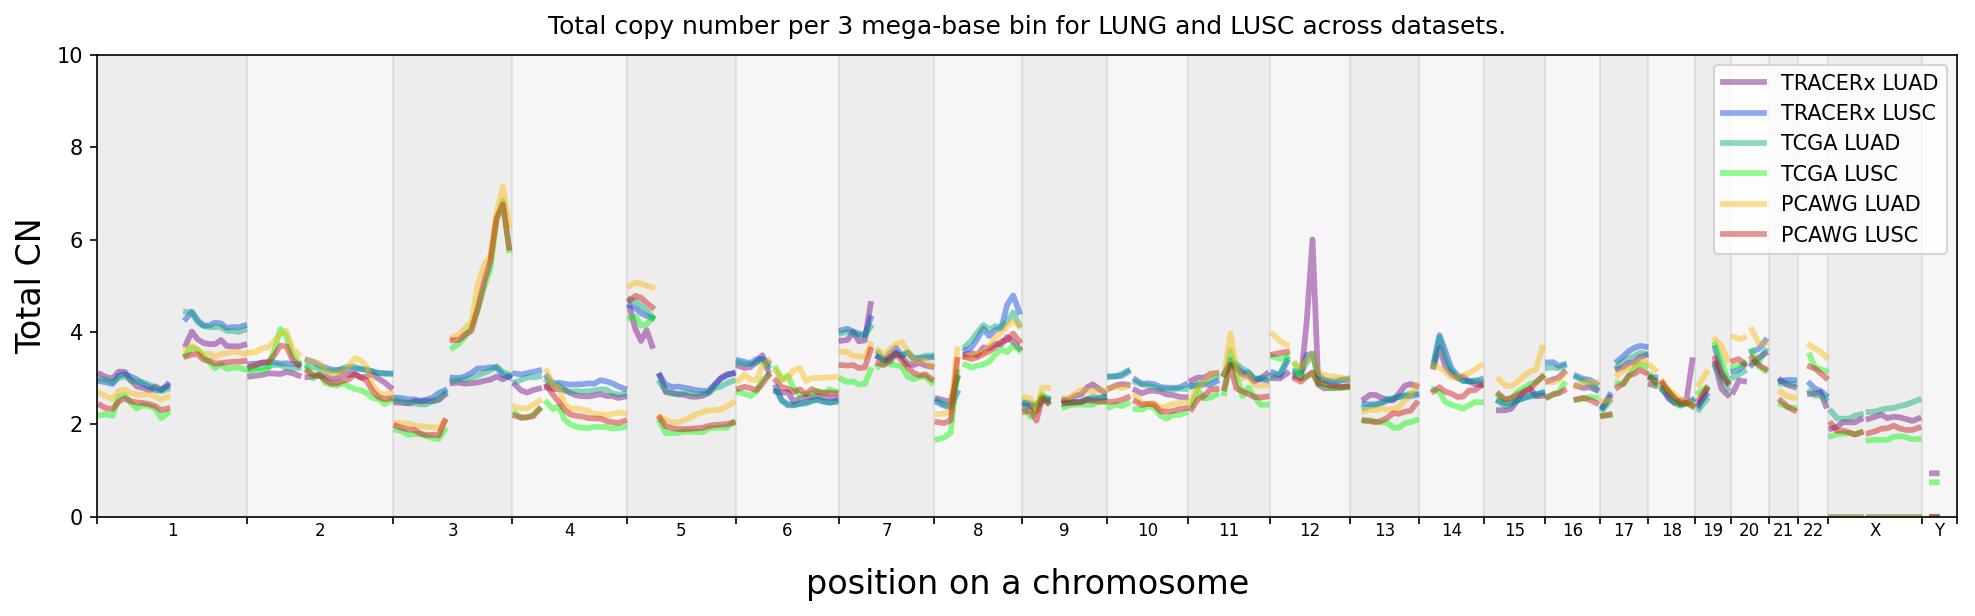

In [8]:
labels = ["TRACERx LUAD", "TRACERx LUSC", "TCGA LUAD", "TCGA LUSC", "PCAWG LUAD", "PCAWG LUSC"]
fig, ax = fig_genome_groups(means_single, labels, alpha=.8, size=0.5, dpi=150)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC across datasets.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_single.pdf", bbox_inches='tight')

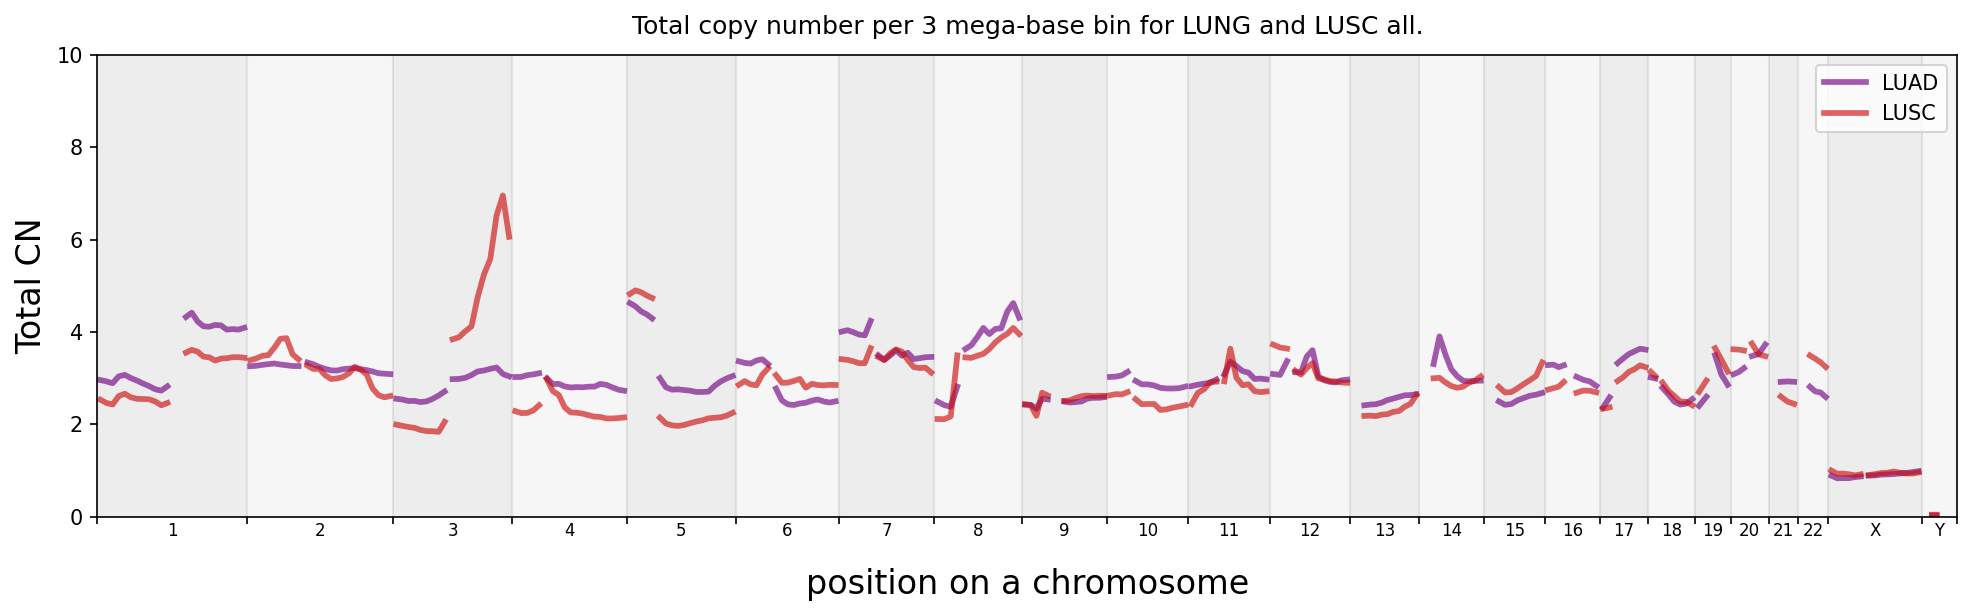

In [9]:
fig, ax = fig_genome_groups(means_all, ["LUAD", "LUSC"], alpha=.8, size=0.5, dpi=150)
ax.set_title("Total copy number per 3 mega-base bin for LUNG and LUSC all.", pad=10)
plt.savefig("../../out/fig_LUAD_LUSC_all.pdf", bbox_inches='tight')

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

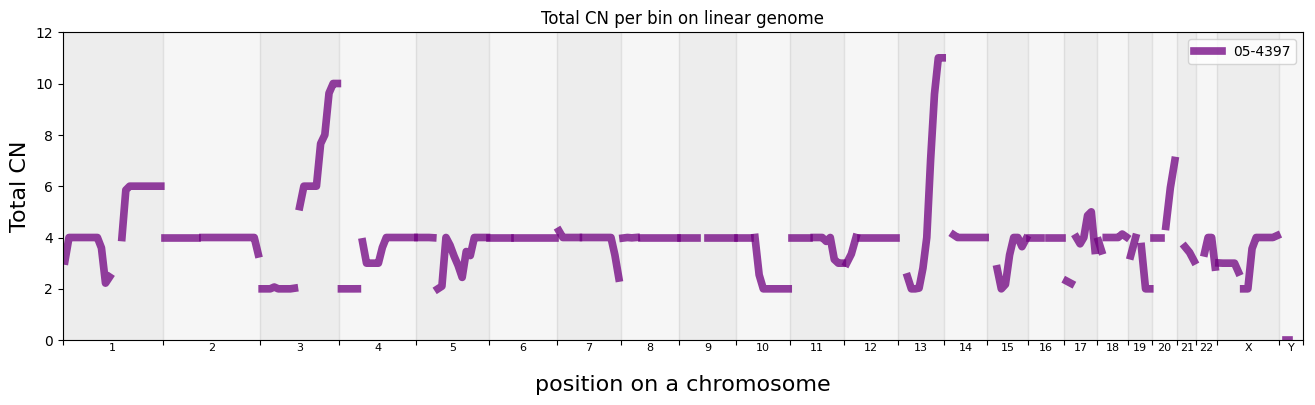

In [10]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUAD'").index[9:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(add_seg_info(select_cns))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig_genome_groups(groups, shorten, alpha=.75, max_cn=12)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: title={'center': 'Total CN per bin on linear genome'}, xlabel='position on a chromosome', ylabel='Total CN'>)

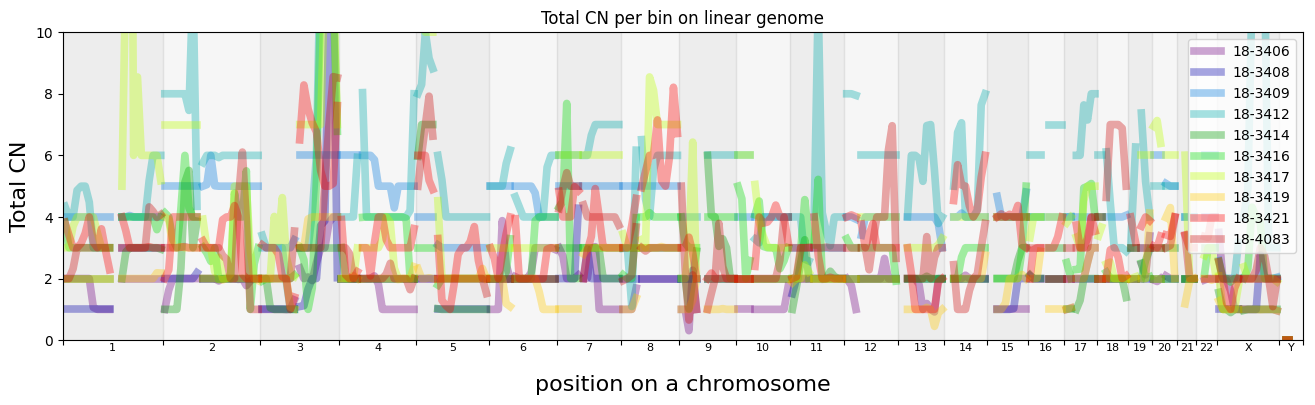

In [11]:
tracer_x_sel_ids = list(samples["TCGA"].query("type == 'LUSC'").index[:10])

groups = []
for id in tracer_x_sel_ids:
	select_cns = cns["TCGA"].set_index("sample_id").loc[id].reset_index()
	groups.append(add_seg_info(select_cns))

shorten = [name[-7:] for name in tracer_x_sel_ids]
fig_genome_groups(groups, shorten, alpha=.75)